# Animal Image Classification Using CNN

## Import Required Libraries

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image_dataset_from_directory
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score

## Set Dataset Path

In [ ]:
# Install kagglehub if needed
!pip install kagglehub

In [ ]:
import os
import kagglehub

# Download Animals-10 dataset directly from Kaggle
path = kagglehub.dataset_download("alessiocorrado99/animals10")

print("Path to dataset files:", path)
print("Files inside downloaded dataset:")
print(os.listdir(path))

Using Colab cache for faster access to the 'animals10' dataset.
Path to dataset files: /kaggle/input/animals10
Files inside downloaded dataset:
['translate.py', 'raw-img']


In [ ]:
import os
import kagglehub

path = kagglehub.dataset_download("alessiocorrado99/animals10")

dataset_path = os.path.join(path, "raw-img")

print("Dataset downloaded to:", path)
print("Final dataset path:", dataset_path)
print("Dataset folders:")
print(os.listdir(dataset_path))

Using Colab cache for faster access to the 'animals10' dataset.
Dataset downloaded to: /kaggle/input/animals10
Final dataset path: /kaggle/input/animals10/raw-img
Dataset folders:
['cavallo', 'pecora', 'elefante', 'gatto', 'scoiattolo', 'gallina', 'ragno', 'mucca', 'cane', 'farfalla']


## Check Dataset Folders and Class Names

In [ ]:
class_translation = {
    "cane": "Dog",
    "gatto": "Cat",
    "cavallo": "Horse",
    "ragno": "Spider",
    "farfalla": "Butterfly",
    "gallina": "Chicken",
    "pecora": "Sheep",
    "mucca": "Cow",
    "scoiattolo": "Squirrel",
    "elefante": "Elephant"
}

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)
    if os.path.isdir(folder_path):
        print(f"{folder} ({class_translation.get(folder, folder)}): {len(os.listdir(folder_path))} images")

cavallo (Horse): 2623 images
pecora (Sheep): 1820 images
elefante (Elephant): 1446 images
gatto (Cat): 1668 images
scoiattolo (Squirrel): 1862 images
gallina (Chicken): 3098 images
ragno (Spider): 4821 images
mucca (Cow): 1866 images
cane (Dog): 4863 images
farfalla (Butterfly): 2112 images


The dataset used is **Animals-10** from Kaggle. It contains images for the following 10 classes:

*   **Dog (cane)**: 4863 images
*   **Cat (gatto)**: 1668 images
*   **Horse (cavallo)**: 2623 images
*   **Spider (ragno)**: 4821 images
*   **Butterfly (farfalla)**: 2112 images
*   **Chicken (gallina)**: 3098 images
*   **Sheep (pecora)**: 1820 images
*   **Cow (mucca)**: 1866 images
*   **Squirrel (scoiattolo)**: 1862 images
*   **Elephant (elefante)**: 1446 images

For training and validation, the `data_loader` function is configured to use only 'Dog', 'Cat', and 'Horse' classes.

## Data Loader Function

In [ ]:
def data_loader(dataset_path, img_size=(96, 96), batch_size=16):
    selected_classes = ["cane", "gatto", "cavallo"]  # Dog, Cat, Horse

    train_dataset = image_dataset_from_directory(
        dataset_path,
        validation_split=0.2,
        subset="training",
        seed=42,
        image_size=img_size,
        batch_size=batch_size,
        class_names=selected_classes
    )

    validation_dataset = image_dataset_from_directory(
        dataset_path,
        validation_split=0.2,
        subset="validation",
        seed=42,
        image_size=img_size,
        batch_size=batch_size,
        class_names=selected_classes
    )

    class_names = train_dataset.class_names

    AUTOTUNE = tf.data.AUTOTUNE
    train_dataset = train_dataset.shuffle(500).prefetch(buffer_size=AUTOTUNE)
    validation_dataset = validation_dataset.prefetch(buffer_size=AUTOTUNE)

    return train_dataset, validation_dataset, class_names

## Load Training and Validation Dataset

In [ ]:
IMG_SIZE = (96, 96)
BATCH_SIZE = 16

train_dataset, validation_dataset, class_names = data_loader(
    dataset_path,
    img_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

print("Class names:", class_names)

class_translation = {
    "cane": "Dog",
    "gatto": "Cat",
    "cavallo": "Horse"
}

english_class_names = [class_translation.get(name, name) for name in class_names]

print("English class names:", english_class_names)

Found 9154 files belonging to 3 classes.
Using 7324 files for training.
Found 9154 files belonging to 3 classes.
Using 1830 files for validation.
Class names: ['cane', 'gatto', 'cavallo']
English class names: ['Dog', 'Cat', 'Horse']


## Visualize Sample Images

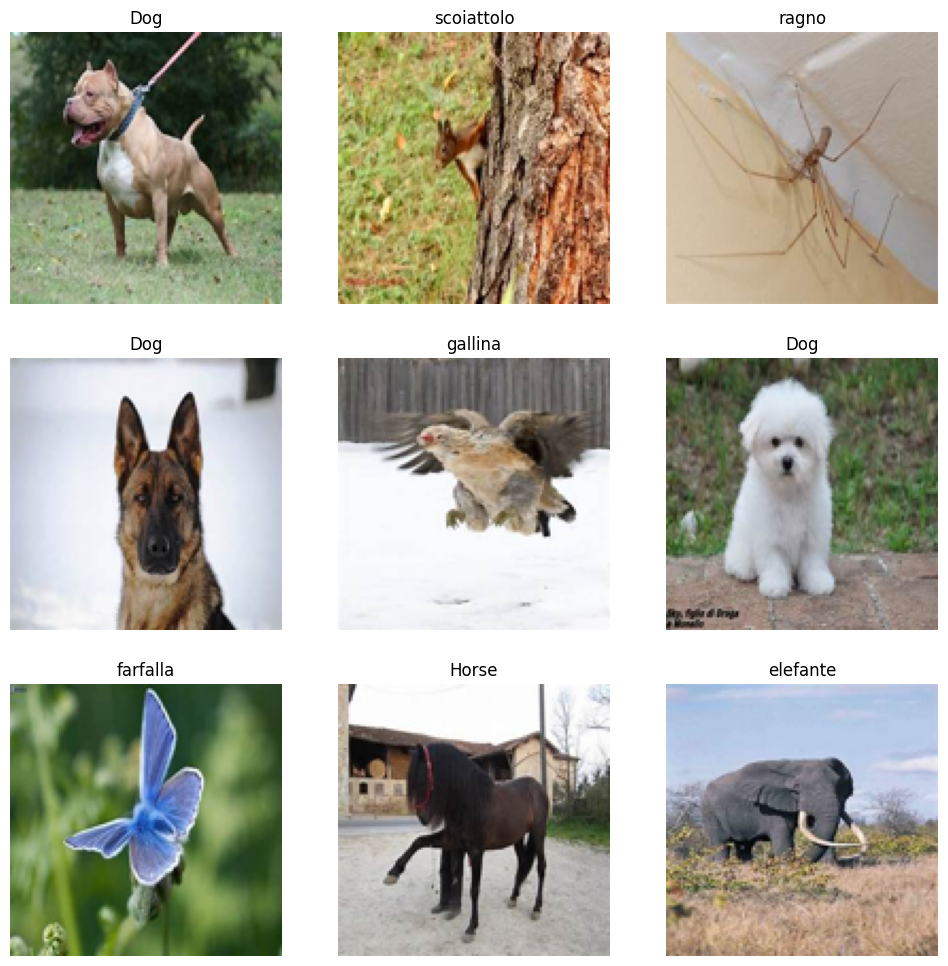

In [ ]:
import random
from PIL import Image

plt.figure(figsize=(12, 12))

folders = [f for f in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, f))]

for i in range(9):
    folder = random.choice(folders)
    folder_path = os.path.join(dataset_path, folder)

    images_in_folder = [
        img for img in os.listdir(folder_path)
        if img.lower().endswith(('.jpg', '.jpeg', '.png'))
    ]

    img_name = random.choice(images_in_folder)
    img_path = os.path.join(folder_path, img_name)

    img = Image.open(img_path).resize((128, 128))

    plt.subplot(3, 3, i + 1)
    plt.imshow(img)

    label_name = class_translation.get(folder, folder)
    plt.title(label_name)
    plt.axis("off")

plt.show()

In [ ]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.25),
    layers.RandomZoom(0.25),
    layers.RandomTranslation(0.15, 0.15),
    layers.RandomContrast(0.25),
    layers.RandomBrightness(0.2),
], name="data_augmentation")

## Build CNN Model

### CNN Model Architecture

In [ ]:
def build_model(input_shape=(96, 96, 3), num_classes=3):
    model = models.Sequential([
        layers.Input(shape=input_shape),

        data_augmentation,

        layers.Rescaling(1./255),

        layers.Conv2D(32, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        layers.Flatten(),

        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5),

        layers.Dense(num_classes, activation='softmax')
    ])

    return model

## Display Model Summary

In [ ]:
model = build_model(
    input_shape=(96, 96, 3),
    num_classes=len(class_names)
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ data_augmentation (Sequential)  │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 20, 20, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 10, 10, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 12800)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,638,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,732,163 (6.61 MB)

 Trainable params: 1,732,163 (6.61 MB)

 Non-trainable params: 0 (0.00 B)

## Compile and Train the Model

In [ ]:
def trainer(model, train_dataset, validation_dataset, epochs=5):
    model.compile(
        optimizer='adam',
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    history = model.fit(
        train_dataset,
        validation_data=validation_dataset,
        epochs=epochs
    )

    return history

## Visualize Training Accuracy and Loss

In [ ]:
EPOCHS = 20

history = trainer(
    model,
    train_dataset,
    validation_dataset,
    epochs=EPOCHS
)

Epoch 1/20
458/458 ━━━━━━━━━━━━━━━━━━━━ 48s 27ms/step - accuracy: 0.5277 - loss: 1.0015 - val_accuracy: 0.5885 - val_loss: 0.9211
Epoch 2/20
458/458 ━━━━━━━━━━━━━━━━━━━━ 15s 16ms/step - accuracy: 0.5665 - loss: 0.9417 - val_accuracy: 0.6191 - val_loss: 0.8583
Epoch 3/20
458/458 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.5815 - loss: 0.9042 - val_accuracy: 0.6475 - val_loss: 0.7769
Epoch 4/20
458/458 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.6065 - loss: 0.8790 - val_accuracy: 0.6295 - val_loss: 0.8156
Epoch 5/20
458/458 ━━━━━━━━━━━━━━━━━━━━ 16s 16ms/step - accuracy: 0.6140 - loss: 0.8620 - val_accuracy: 0.5699 - val_loss: 0.9008
Epoch 6/20
458/458 ━━━━━━━━━━━━━━━━━━━━ 16s 17ms/step - accuracy: 0.6238 - loss: 0.8416 - val_accuracy: 0.6760 - val_loss: 0.7352
Epoch 7/20
458/458 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.6305 - loss: 0.8205 - val_accuracy: 0.5607 - val_loss: 1.0174
Epoch 8/20
458/458 ━━━━━━━━━━━━━━━━━━━━ 15s 15ms/step - accuracy: 0.6430 - loss: 0.8050 - 

## Evaluate the Model

In [ ]:
def visualize_training(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']

    loss = history.history['loss']
    val_loss = history.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, marker='o', label='Training accuracy')
    plt.plot(epochs_range, val_acc, marker='o', label='Validation accuracy')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, marker='o', label='Training loss')
    plt.plot(epochs_range, val_loss, marker='o', label='Validation loss')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

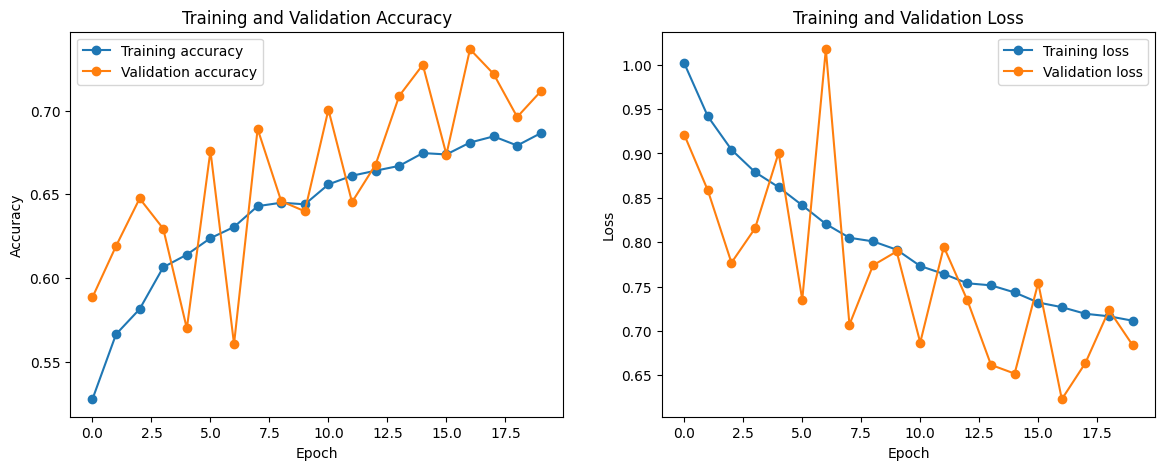

In [ ]:
visualize_training(history)

## Display Classification Report

In [ ]:
def evaluate_model(model, validation_dataset, class_names):
    y_true = []
    y_pred = []

    for images, labels in validation_dataset:
        predictions = model.predict(images, verbose=0)
        predicted_labels = np.argmax(predictions, axis=1)

        y_true.extend(labels.numpy())
        y_pred.extend(predicted_labels)

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')

    print("Evaluation Metrics")
    print("------------------")
    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1-score:  {f1:.4f}")

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_names))

    return y_true, y_pred

## Display Confusion Matrix

In [ ]:
y_true, y_pred = evaluate_model(
    model,
    validation_dataset,
    english_class_names
)

Evaluation Metrics
------------------
Accuracy:  0.7115
Precision: 0.7369
Recall:    0.7115
F1-score:  0.6829

Classification Report:
              precision    recall  f1-score   support

         Dog       0.73      0.80      0.76       982
         Cat       0.88      0.20      0.33       322
       Horse       0.67      0.86      0.75       526

    accuracy                           0.71      1830
   macro avg       0.76      0.62      0.62      1830
weighted avg       0.74      0.71      0.68      1830



## Visualize Confusion Matrix

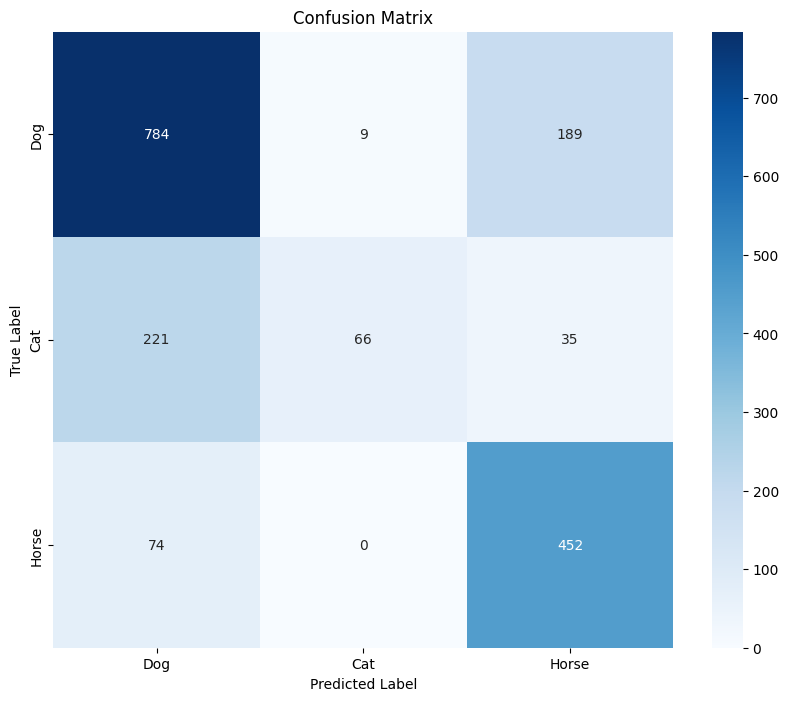

In [ ]:
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=english_class_names,
    yticklabels=english_class_names,
    cmap='Blues'
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

## Visualize Misclassified Images

In [ ]:
def visualize_misclassifications(model, validation_dataset, class_names, max_images=9):
    misclassified_images = []
    true_labels = []
    predicted_labels = []

    for images, labels in validation_dataset:
        predictions = model.predict(images, verbose=0)
        preds = np.argmax(predictions, axis=1)

        for i in range(len(labels)):
            if labels[i].numpy() != preds[i]:
                misclassified_images.append(images[i].numpy().astype("uint8"))
                true_labels.append(labels[i].numpy())
                predicted_labels.append(preds[i])

            if len(misclassified_images) >= max_images:
                break

        if len(misclassified_images) >= max_images:
            break

    plt.figure(figsize=(12, 12))

    for i in range(len(misclassified_images)):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(misclassified_images[i])

        true_name = class_names[true_labels[i]]
        pred_name = class_names[predicted_labels[i]]

        plt.title(f"True: {true_name}\nPred: {pred_name}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

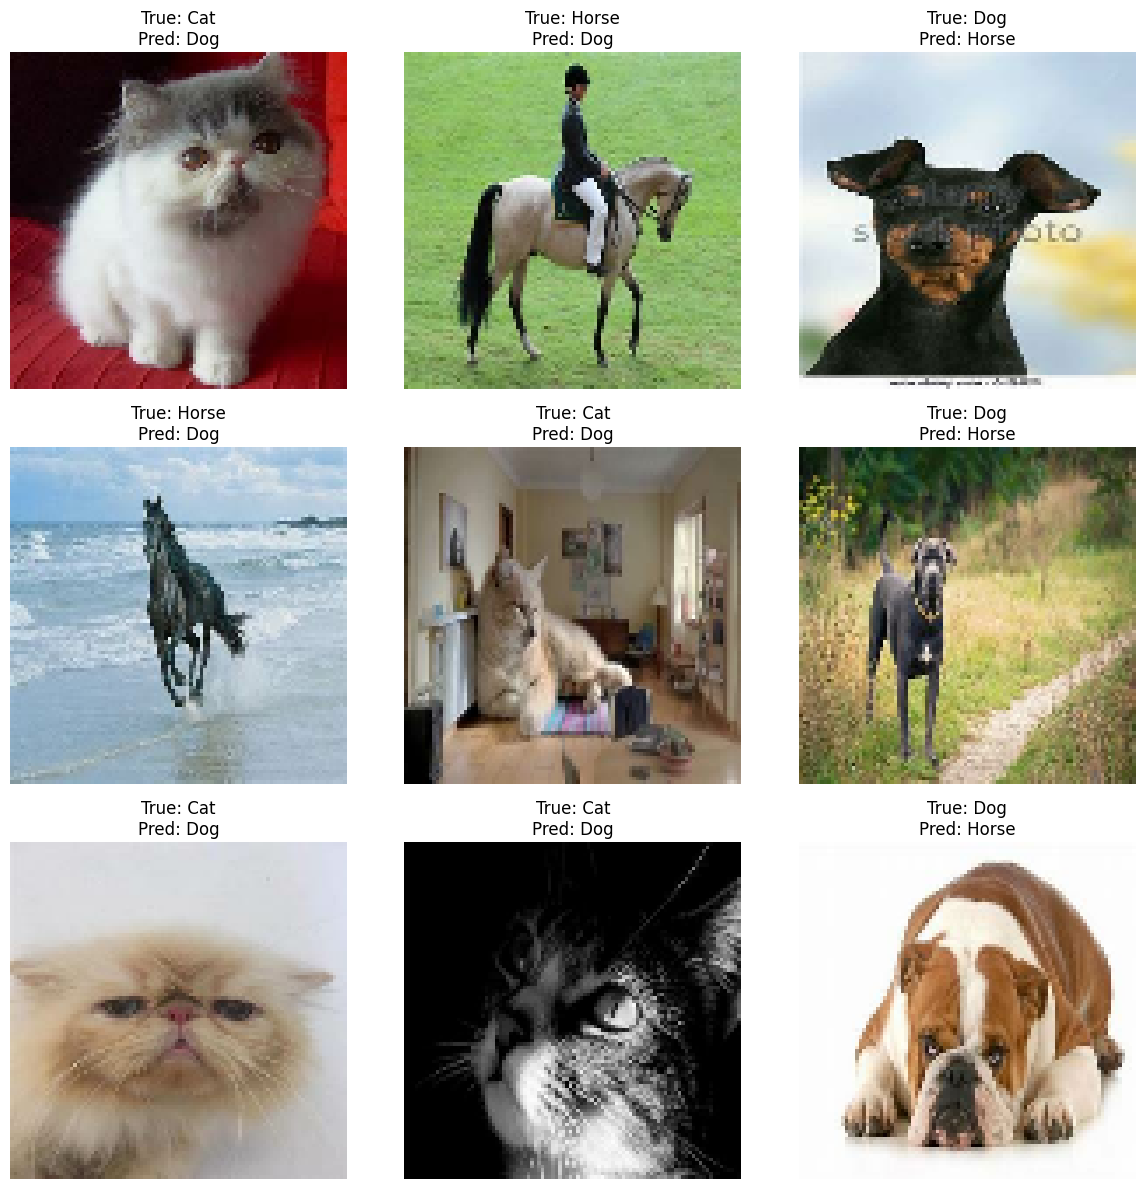

In [ ]:
visualize_misclassifications(
    model,
    validation_dataset,
    english_class_names,
    max_images=9
)

## Save the Trained Model

In [ ]:
# model.save("/content/drive/MyDrive/animal_classifier_cnn_model.h5")
# print("Model saved successfully!")

## Test the Model on a Single Image

In [ ]:
from tensorflow.keras.preprocessing import image

def predict_single_image(model, image_path, class_names):
    img = image.load_img(image_path, target_size=(128, 128))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)

    predictions = model.predict(img_array)
    predicted_index = np.argmax(predictions)
    confidence = np.max(predictions)

    plt.imshow(img)
    plt.axis("off")
    plt.title(f"Prediction: {class_names[predicted_index]}\nConfidence: {confidence:.2f}")
    plt.show()

    return class_names[predicted_index], confidence

## Conclusion

In this project, a Convolutional Neural Network was built to classify images from the Animals-10 dataset. The dataset contained multiple animal categories, and the images were loaded from Google Drive using Keras preprocessing tools.

The CNN model was trained and evaluated using validation accuracy, precision, recall, and F1-score. The training and validation graphs showed how the model improved over time. Misclassified images were also visualized to better understand where the model made mistakes.

The model performed reasonably well for a basic CNN. Future improvements could include increasing the number of epochs, using data augmentation, tuning hyperparameters, or applying transfer learning with a pretrained model such as MobileNetV2 or ResNet50.